# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [18]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [19]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [20]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [21]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


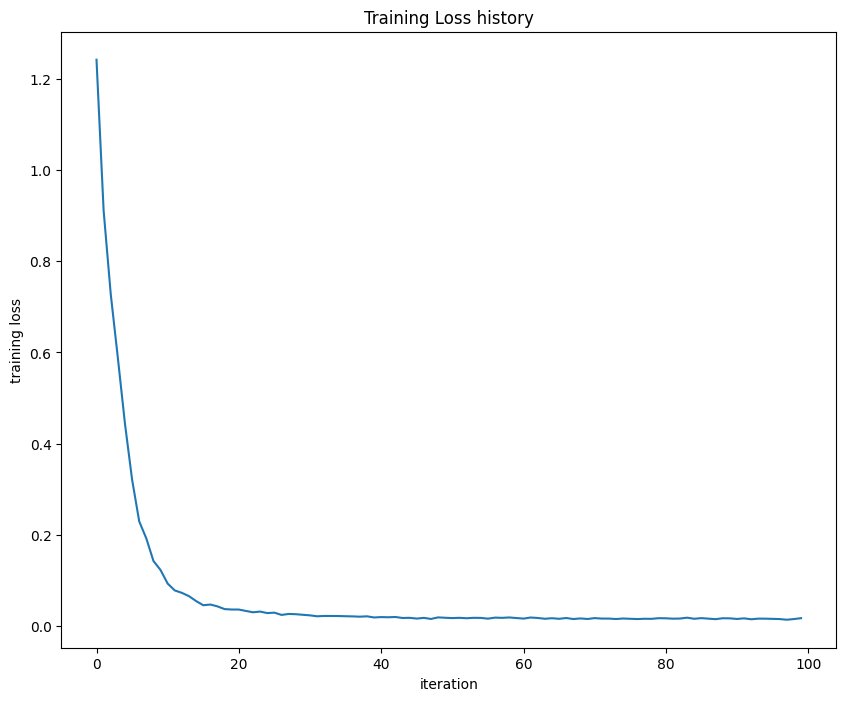

In [22]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [23]:
input_size = 64
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

digits = load_digits()

X = digits.data
y = digits.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25
)

mean_image = np.mean(X_train, axis=0)

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302594
iteration 100 / 1000: loss 2.302594
iteration 200 / 1000: loss 2.302591
iteration 300 / 1000: loss 2.302594
iteration 400 / 1000: loss 2.302588
iteration 500 / 1000: loss 2.302589
iteration 600 / 1000: loss 2.302591
iteration 700 / 1000: loss 2.302590
iteration 800 / 1000: loss 2.302590
iteration 900 / 1000: loss 2.302590
Validation accuracy:  0.07777777777777778


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

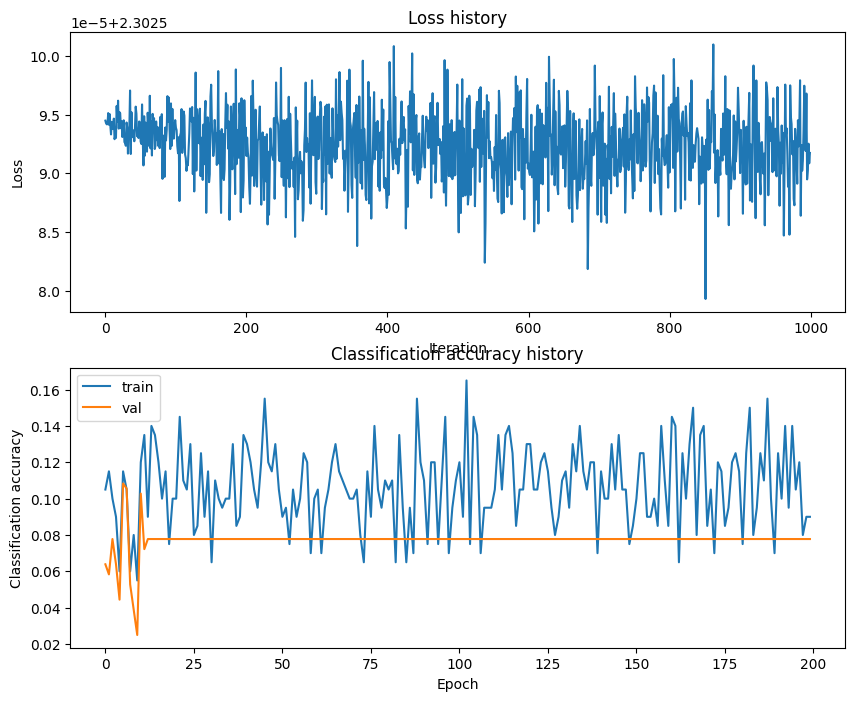

In [24]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

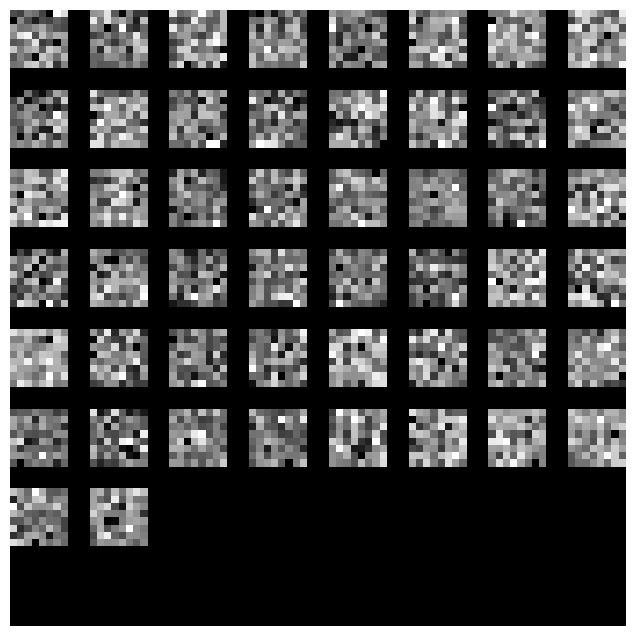

In [25]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(8, 8, 1, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3), cmap='gray')
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

In [26]:
best_net = None
best_val_acc = -1
results = {}

learning_rates = [1e-2, 5e-2, 1e-1]
regularization_strengths = [0.1, 0.25, 0.5, 1e-4]
hidden_sizes = [50, 100, 150]

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularization_strengths:
            net = TwoLayerNet(input_size, hs, num_classes)

            stats = net.train(X_train, y_train, X_val, y_val,
                              num_iters=1500, batch_size=200,
                              learning_rate=lr, learning_rate_decay=0.95,
                              reg=reg, verbose=False)

            val_acc = (net.predict(X_val) == y_val).mean()
            results[(hs, lr, reg)] = val_acc

            if val_acc > best_val_acc:
                best_lr = lr
                best_reg = reg
                best_hs = hs
                best_val_acc = val_acc
                best_net = net

for hs, lr, reg in sorted(results):
    val_acc = results[(hs, lr, reg)]
    print(f'hs {hs} lr {lr} reg {reg} val accuracy: {val_acc:.4f}')


print(f'Лучшая точность на валидации: {best_val_acc:.4f}')

hs 50 lr 0.01 reg 0.0001 val accuracy: 0.0778
hs 50 lr 0.01 reg 0.1 val accuracy: 0.0778
hs 50 lr 0.01 reg 0.25 val accuracy: 0.0889
hs 50 lr 0.01 reg 0.5 val accuracy: 0.0778
hs 50 lr 0.05 reg 0.0001 val accuracy: 0.8528
hs 50 lr 0.05 reg 0.1 val accuracy: 0.8167
hs 50 lr 0.05 reg 0.25 val accuracy: 0.6833
hs 50 lr 0.05 reg 0.5 val accuracy: 0.4778
hs 50 lr 0.1 reg 0.0001 val accuracy: 0.9694
hs 50 lr 0.1 reg 0.1 val accuracy: 0.9500
hs 50 lr 0.1 reg 0.25 val accuracy: 0.8917
hs 50 lr 0.1 reg 0.5 val accuracy: 0.8028
hs 100 lr 0.01 reg 0.0001 val accuracy: 0.0889
hs 100 lr 0.01 reg 0.1 val accuracy: 0.0778
hs 100 lr 0.01 reg 0.25 val accuracy: 0.0778
hs 100 lr 0.01 reg 0.5 val accuracy: 0.0778
hs 100 lr 0.05 reg 0.0001 val accuracy: 0.8528
hs 100 lr 0.05 reg 0.1 val accuracy: 0.8417
hs 100 lr 0.05 reg 0.25 val accuracy: 0.7583
hs 100 lr 0.05 reg 0.5 val accuracy: 0.5583
hs 100 lr 0.1 reg 0.0001 val accuracy: 0.9722
hs 100 lr 0.1 reg 0.1 val accuracy: 0.9472
hs 100 lr 0.1 reg 0.25 val 

In [27]:
test_acc = (best_net.predict(X_test) == y_test).mean()
print(f'Best model parameters: hidden_size={best_hs}, lr={best_lr}, reg={best_reg}')
print('Test accuracy: ', test_acc)

Best model parameters: hidden_size=100, lr=0.1, reg=0.0001
Test accuracy:  0.9527777777777777


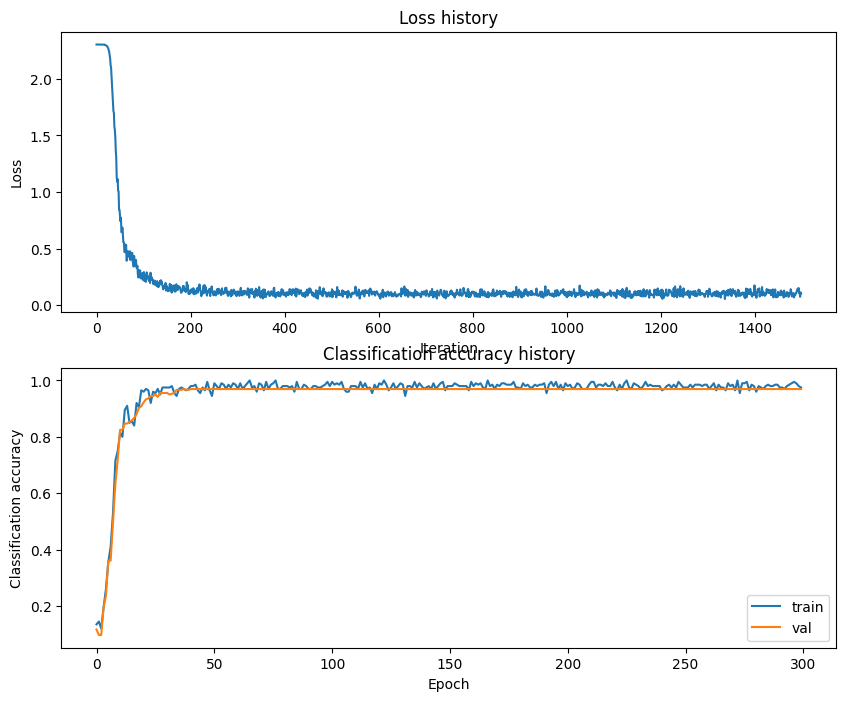

In [28]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

Сделайте выводы по результатам работы.

В ходе выполнения второй работы была спроектирована и обучена двухслойная полносвязная нейронная сеть с нелинейной функцией активации ReLU. Реализация прямого прохода и функции потерь Softmax позволила модели эффективно классифицировать изображения цифр, при этом начальное значение потерь подтвердило теоретическую корректность расчетов. Векторизованный метод обратного распространения ошибки обеспечил высокую скорость вычисления градиентов для всех слоев сети, что важно для итеративного процесса обучения.

Результаты подбора гиперпараметров показали, что модель достигает пиковой точности при увеличении скорости обучения до 0.1 и минимизации регуляризации. Низкий шаг обучения не позволяет сети выйти из состояния недообученности, в то время как расширение скрытого слоя нейронов способствует лучшему извлечению признаков. Итоговая архитектура продемонстрировала превосходство над линейными методами, успешно адаптируясь к сложным закономерностям данных при сохранении высокой обобщающей способности.